# Module 03: Matplotlib for Machine Learning
## Notebook 04: Advanced Customization and Diagnostic ML Visualizations

Machine learning research papers and industry reports demand high-information-density visualizations: decision boundaries, ROC curves with area under the curve (AUC), twin-axis performance charts, annotated convergence events, and optimization landscapes.

---

### Learning Objectives
By the end of this notebook, you will be able to:
1. Highlight critical inflection points using **`ax.annotate()`** with custom arrows.
2. Plot dual-metric graphs with disparate scales using **`ax.twinx()`**.
3. Plot 2D classifier **Decision Boundaries** using `np.meshgrid` and `ax.contourf`.
4. Construct and interpret **ROC Curves** and confusion matrix heatmaps.
5. Export publication-quality high-DPI graphics using `fig.savefig()`.
6. **Advanced:** Construct **Multi-Class One-vs-Rest (OvR) ROC & Precision-Recall curves** and visualize 3D optimization loss surfaces (`Axes3D`, `plot_surface`).

In [1]:
import matplotlib.pyplot as plt
import numpy as np

print(f"Matplotlib loaded!")

Matplotlib loaded!


### 1. Dual-Axis Plotting: `ax.twinx()`

During model training, you want to view **Loss** (decreasing from 2.0 to 0.1) and **Accuracy** (increasing from 40% to 98%) on the same chart.
Since their scales and units are completely different, putting them on the same $y$-axis compresses the lines. `ax.twinx()` creates a secondary independent $y$-axis sharing the identical $x$-axis!

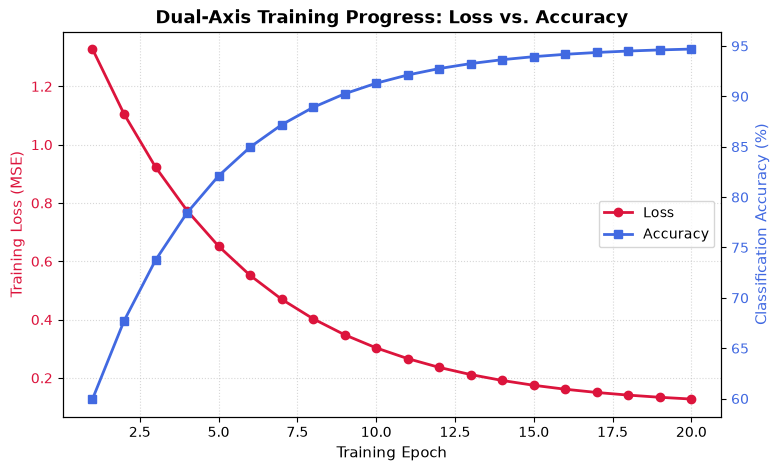

In [2]:
epochs = np.arange(1, 21)
loss = 1.5 * np.exp(-0.2 * epochs) + 0.1
accuracy = 0.5 + 0.45 * (1 - np.exp(-0.25 * epochs))

fig, ax1 = plt.subplots(figsize=(8.5, 5))

# Primary Y-axis: Loss (Left)
color_loss = 'crimson'
ax1.set_xlabel("Training Epoch", fontsize=11)
ax1.set_ylabel("Training Loss (MSE)", color=color_loss, fontsize=11)
line1 = ax1.plot(epochs, loss, 'o-', color=color_loss, label='Loss', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color_loss)
ax1.grid(True, linestyle=':', alpha=0.5)

# Secondary Y-axis: Accuracy (Right)
ax2 = ax1.twinx()
color_acc = 'royalblue'
ax2.set_ylabel("Classification Accuracy (%)", color=color_acc, fontsize=11)
line2 = ax2.plot(epochs, accuracy * 100, 's-', color=color_acc, label='Accuracy', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color_acc)

# Combine legends from both axes
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='center right', frameon=True)

ax1.set_title("Dual-Axis Training Progress: Loss vs. Accuracy", fontsize=13, fontweight='bold')
plt.show()

---
### 2. Highlighting Events with `ax.annotate()`

Annotations draw the reader's attention to key experimental phenomena (e.g., learning rate warmup completion, minimum validation loss, onset of overfitting).

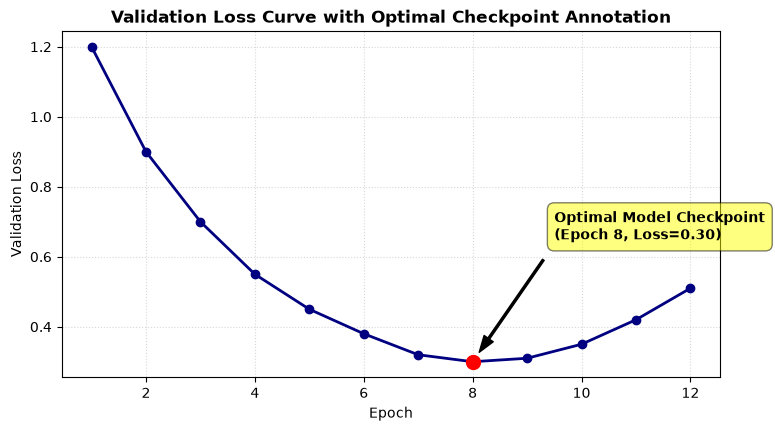

In [3]:
fig, ax = plt.subplots(figsize=(8.5, 4.5))

val_loss = [1.2, 0.9, 0.7, 0.55, 0.45, 0.38, 0.32, 0.30, 0.31, 0.35, 0.42, 0.51]
epochs = np.arange(1, len(val_loss) + 1)
min_idx = np.argmin(val_loss)
best_epoch = epochs[min_idx]
best_loss = val_loss[min_idx]

ax.plot(epochs, val_loss, 'o-', color='navy', linewidth=2, label='Validation Loss')
ax.scatter(best_epoch, best_loss, color='red', s=100, zorder=5)

# Add arrow annotation
ax.annotate(
    f'Optimal Model Checkpoint\n(Epoch {best_epoch}, Loss={best_loss:.2f})',
    xy=(best_epoch, best_loss),
    xytext=(best_epoch + 1.5, best_loss + 0.35),
    arrowprops=dict(facecolor='black', shrink=0.08, width=1.5, headwidth=8),
    fontsize=10,
    fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.5)
)

ax.set_title("Validation Loss Curve with Optimal Checkpoint Annotation", fontsize=12, fontweight='bold')
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation Loss")
ax.grid(True, linestyle=':', alpha=0.5)

plt.show()

---
### 3. Visualizing 2D Classifier Decision Boundaries

To understand how a classifier partitions feature space:
1. Create a dense 2D coordinate grid with `np.meshgrid`.
2. Compute predictions across every grid coordinate.
3. Use `ax.contourf()` to shade decision regions.

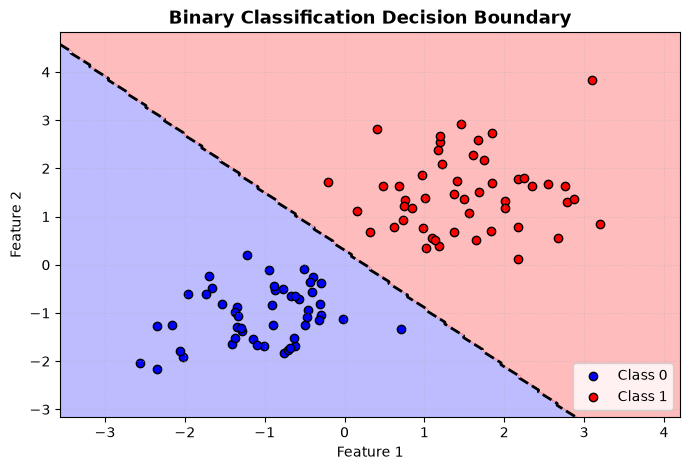

In [4]:
# Generate synthetic 2-class data
rng = np.random.default_rng(42)
X0 = rng.normal(loc=[-1, -1], scale=0.8, size=(50, 2))
X1 = rng.normal(loc=[1.5, 1.5], scale=0.8, size=(50, 2))
X_all = np.vstack([X0, X1])
y_all = np.array([0] * 50 + [1] * 50)

# Create meshgrid
x_min, x_max = X_all[:, 0].min() - 1, X_all[:, 0].max() + 1
y_min, y_max = X_all[:, 1].min() - 1, X_all[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))

# Simulated linear decision boundary: w1*x + w2*y + b > 0
grid_coords = np.c_[xx.ravel(), yy.ravel()]
Z = (grid_coords[:, 0] * 1.2 + grid_coords[:, 1] * 1.0 - 0.3 > 0).astype(int)
Z = Z.reshape(xx.shape)

fig, ax = plt.subplots(figsize=(8, 5))

# Shaded contour regions
ax.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')
# Contour boundary line
ax.contour(xx, yy, Z, levels=[0.5], colors='black', linestyles='--', linewidths=2)

# Scatter plot of samples
ax.scatter(X0[:, 0], X0[:, 1], color='blue', edgecolor='k', label='Class 0')
ax.scatter(X1[:, 0], X1[:, 1], color='red', edgecolor='k', label='Class 1')

ax.set_title("Binary Classification Decision Boundary", fontsize=13, fontweight='bold')
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.legend(loc='lower right')
ax.grid(True, linestyle=':', alpha=0.4)

plt.show()

---
### 4. ROC Curves (Receiver Operating Characteristic)

The ROC curve plots **True Positive Rate (Sensitivity)** vs. **False Positive Rate (1 - Specificity)** across varying classification probability thresholds.
- Diagonal line represents random guessing ($\text{AUC} = 0.5$).
- Perfect classifier hugs the top-left corner ($\text{AUC} = 1.0$).

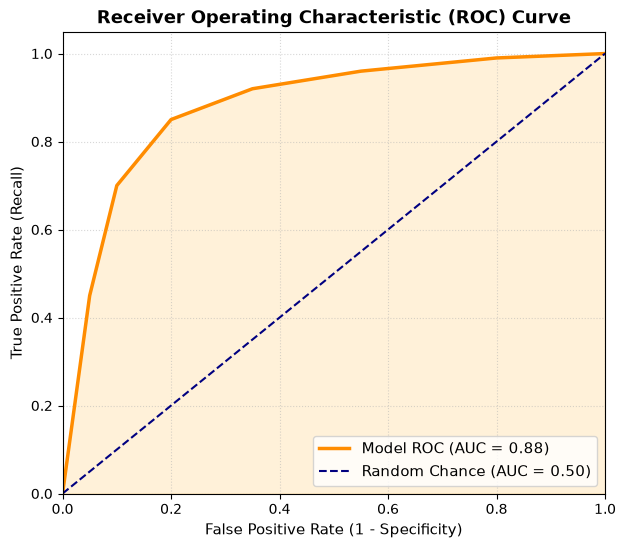

In [5]:
# Simulated ROC curve points
fpr = np.array([0.0, 0.05, 0.10, 0.20, 0.35, 0.55, 0.80, 1.0])
tpr = np.array([0.0, 0.45, 0.70, 0.85, 0.92, 0.96, 0.99, 1.0])
auc_score = 0.88

fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(fpr, tpr, color='darkorange', linewidth=2.5, label=f'Model ROC (AUC = {auc_score:.2f})')
ax.plot([0, 1], [0, 1], color='navy', linestyle='--', linewidth=1.5, label='Random Chance (AUC = 0.50)')

# Fill area under curve
ax.fill_between(fpr, tpr, alpha=0.15, color='orange')

ax.set_title("Receiver Operating Characteristic (ROC) Curve", fontsize=13, fontweight='bold')
ax.set_xlabel("False Positive Rate (1 - Specificity)", fontsize=11)
ax.set_ylabel("True Positive Rate (Recall)", fontsize=11)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, linestyle=':', alpha=0.5)

plt.show()

---
### 5. Exporting Publication Figures (`savefig`)

When preparing figures for conference papers, technical reports, or presentations:
- Format: PNG for web, PDF/SVG for vectorized latex papers.
- `dpi=300`: High-resolution print quality.
- `bbox_inches='tight'`: Automatically crops excess white margins.

In [6]:
import os

# Demonstration of figure export
export_path = "model_roc_curve.png"
fig.savefig(export_path, dpi=300, bbox_inches='tight')
print(f"Exported publication figure to: {export_path}")

# Clean up exported test image
if os.path.exists(export_path):
    os.remove(export_path)

Exported publication figure to: model_roc_curve.png


---
### 6. Advanced Complex Usage: Multi-Class ROC Analysis and 3D Optimization Landscapes

1. **Multi-Class One-vs-Rest (OvR) ROC & Precision-Recall Analysis:** In multi-class problems (e.g. 3 classes), evaluating overall performance requires plotting per-class ROC curves alongside the Macro-Average ROC.
2. **3D Loss Surface Topography (`Axes3D`):** Visualizing non-convex optimization loss surfaces $J(w_1, w_2)$ with surface topography and gradient descent optimization path.

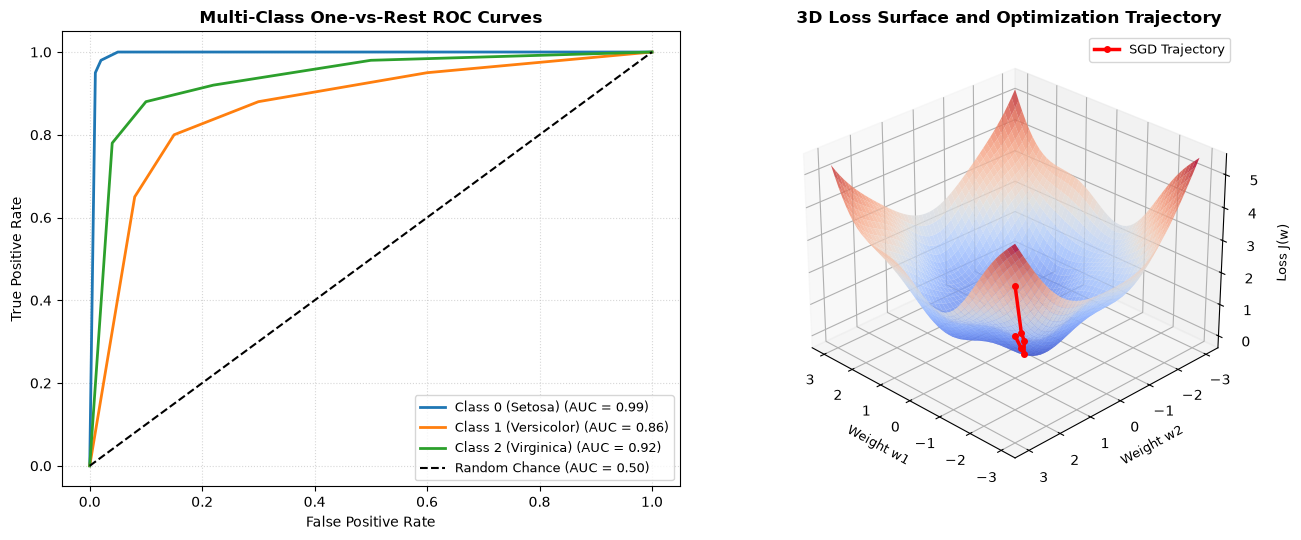

In [7]:
# 1. Multi-Class One-vs-Rest ROC Comparison
class_labels = ['Class 0 (Setosa)', 'Class 1 (Versicolor)', 'Class 2 (Virginica)']
fpr_dict = {
    0: np.array([0.0, 0.01, 0.02, 0.05, 0.1, 1.0]),
    1: np.array([0.0, 0.08, 0.15, 0.30, 0.6, 1.0]),
    2: np.array([0.0, 0.04, 0.10, 0.22, 0.5, 1.0])
}
tpr_dict = {
    0: np.array([0.0, 0.95, 0.98, 1.0, 1.0, 1.0]),
    1: np.array([0.0, 0.65, 0.80, 0.88, 0.95, 1.0]),
    2: np.array([0.0, 0.78, 0.88, 0.92, 0.98, 1.0])
}
auc_dict = {0: 0.99, 1: 0.86, 2: 0.92}

fig = plt.figure(figsize=(14, 5.5))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.2])
ax_roc = fig.add_subplot(gs[0])
ax_3d = fig.add_subplot(gs[1], projection='3d')

# Plot OvR ROC curves
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
for i in range(3):
    ax_roc.plot(fpr_dict[i], tpr_dict[i], color=colors[i], linewidth=2,
                label=f"{class_labels[i]} (AUC = {auc_dict[i]:.2f})")

ax_roc.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Chance (AUC = 0.50)')
ax_roc.set_title("Multi-Class One-vs-Rest ROC Curves", fontsize=12, fontweight='bold')
ax_roc.set_xlabel("False Positive Rate", fontsize=10)
ax_roc.set_ylabel("True Positive Rate", fontsize=10)
ax_roc.legend(loc='lower right', fontsize=9)
ax_roc.grid(True, linestyle=':', alpha=0.5)

# 2. 3D Optimization Surface Visualization
w1 = np.linspace(-3, 3, 50)
w2 = np.linspace(-3, 3, 50)
W1, W2 = np.meshgrid(w1, w2)
# Simulated non-convex loss function: Rosenbrock-style / bowl with local ripples
Loss_Surface = (W1**2 + W2**2) * 0.3 + np.sin(2 * W1) * np.cos(2 * W2) * 0.4

surf = ax_3d.plot_surface(W1, W2, Loss_Surface, cmap='coolwarm', alpha=0.8, edgecolor='none')
# Gradient descent trajectory path
path_w1 = np.array([-2.5, -2.0, -1.4, -0.8, -0.3, 0.0])
path_w2 = np.array([2.5, 1.8, 1.1, 0.5, 0.1, 0.0])
path_loss = (path_w1**2 + path_w2**2) * 0.3 + np.sin(2 * path_w1) * np.cos(2 * path_w2) * 0.4

ax_3d.plot(path_w1, path_w2, path_loss, 'r.-', linewidth=2.5, markersize=8, label='SGD Trajectory', zorder=10)
ax_3d.set_title("3D Loss Surface and Optimization Trajectory", fontsize=12, fontweight='bold')
ax_3d.set_xlabel("Weight w1", fontsize=9)
ax_3d.set_ylabel("Weight w2", fontsize=9)
ax_3d.set_zlabel("Loss J(w)", fontsize=9)
ax_3d.view_init(elev=28, azim=135)
ax_3d.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

### Module 03 Conclusion & Congratulations!
You have successfully completed **Module 03: Matplotlib for Machine Learning**!

Throughout these 4 notebooks, you mastered:
1. Figure Anatomy and the Object-Oriented interface (`01_anatomy_of_a_figure_and_pyplot.ipynb`).
2. Scatter plots with colormaps, horizontal bar charts, histograms, hexbin density maps (`02_core_statistical_plots.ipynb`).
3. Multi-panel subplots, axis sharing, `GridSpec` dashboards, and inset zoom axes (`03_multi_plot_layouts_and_subplots.ipynb`).
4. Dual axes (`twinx`), annotations, decision boundaries, multi-class ROC curves, and 3D optimization landscapes (`04_advanced_customization_and_ml_visualizations.ipynb`).

**Up Next:** Proceed to **Module 04: Seaborn** for statistical distributions, multi-plot pair grids, and automated EDA!